# Image Classification with a CNN — Fashion-MNIST

In this lab we build a **Convolutional Neural Network (CNN)** from scratch in PyTorch to
recognise clothing items from the **Fashion-MNIST** dataset.

Each image is a tiny **28×28 grayscale** picture of a clothing item (shirt, shoe, bag, …),
and our job is to predict which of **10 categories** it belongs to.

**What you'll do in this notebook**
1. Load and *look at* the data
2. Prepare it for PyTorch (normalise → tensors → batches)
3. Build the CNN shown in the architecture diagram below
4. Train it and watch accuracy improve every epoch
5. Evaluate it and predict a single unseen image


## Why a CNN? (quick intuition)

A normal fully-connected network would flatten the image into 784 numbers and lose all
information about *which pixel is next to which*. But in images, **nearby pixels form
patterns** — edges, corners, curves — and those patterns can appear *anywhere* in the image.

A **CNN** solves this by sliding small learnable **filters** across the image. The same filter
looks for the same pattern everywhere, so the network learns *shapes* (an edge, a sleeve, a sole)
instead of memorising exact pixel positions. This makes CNNs far better — and far more
efficient — at image tasks.


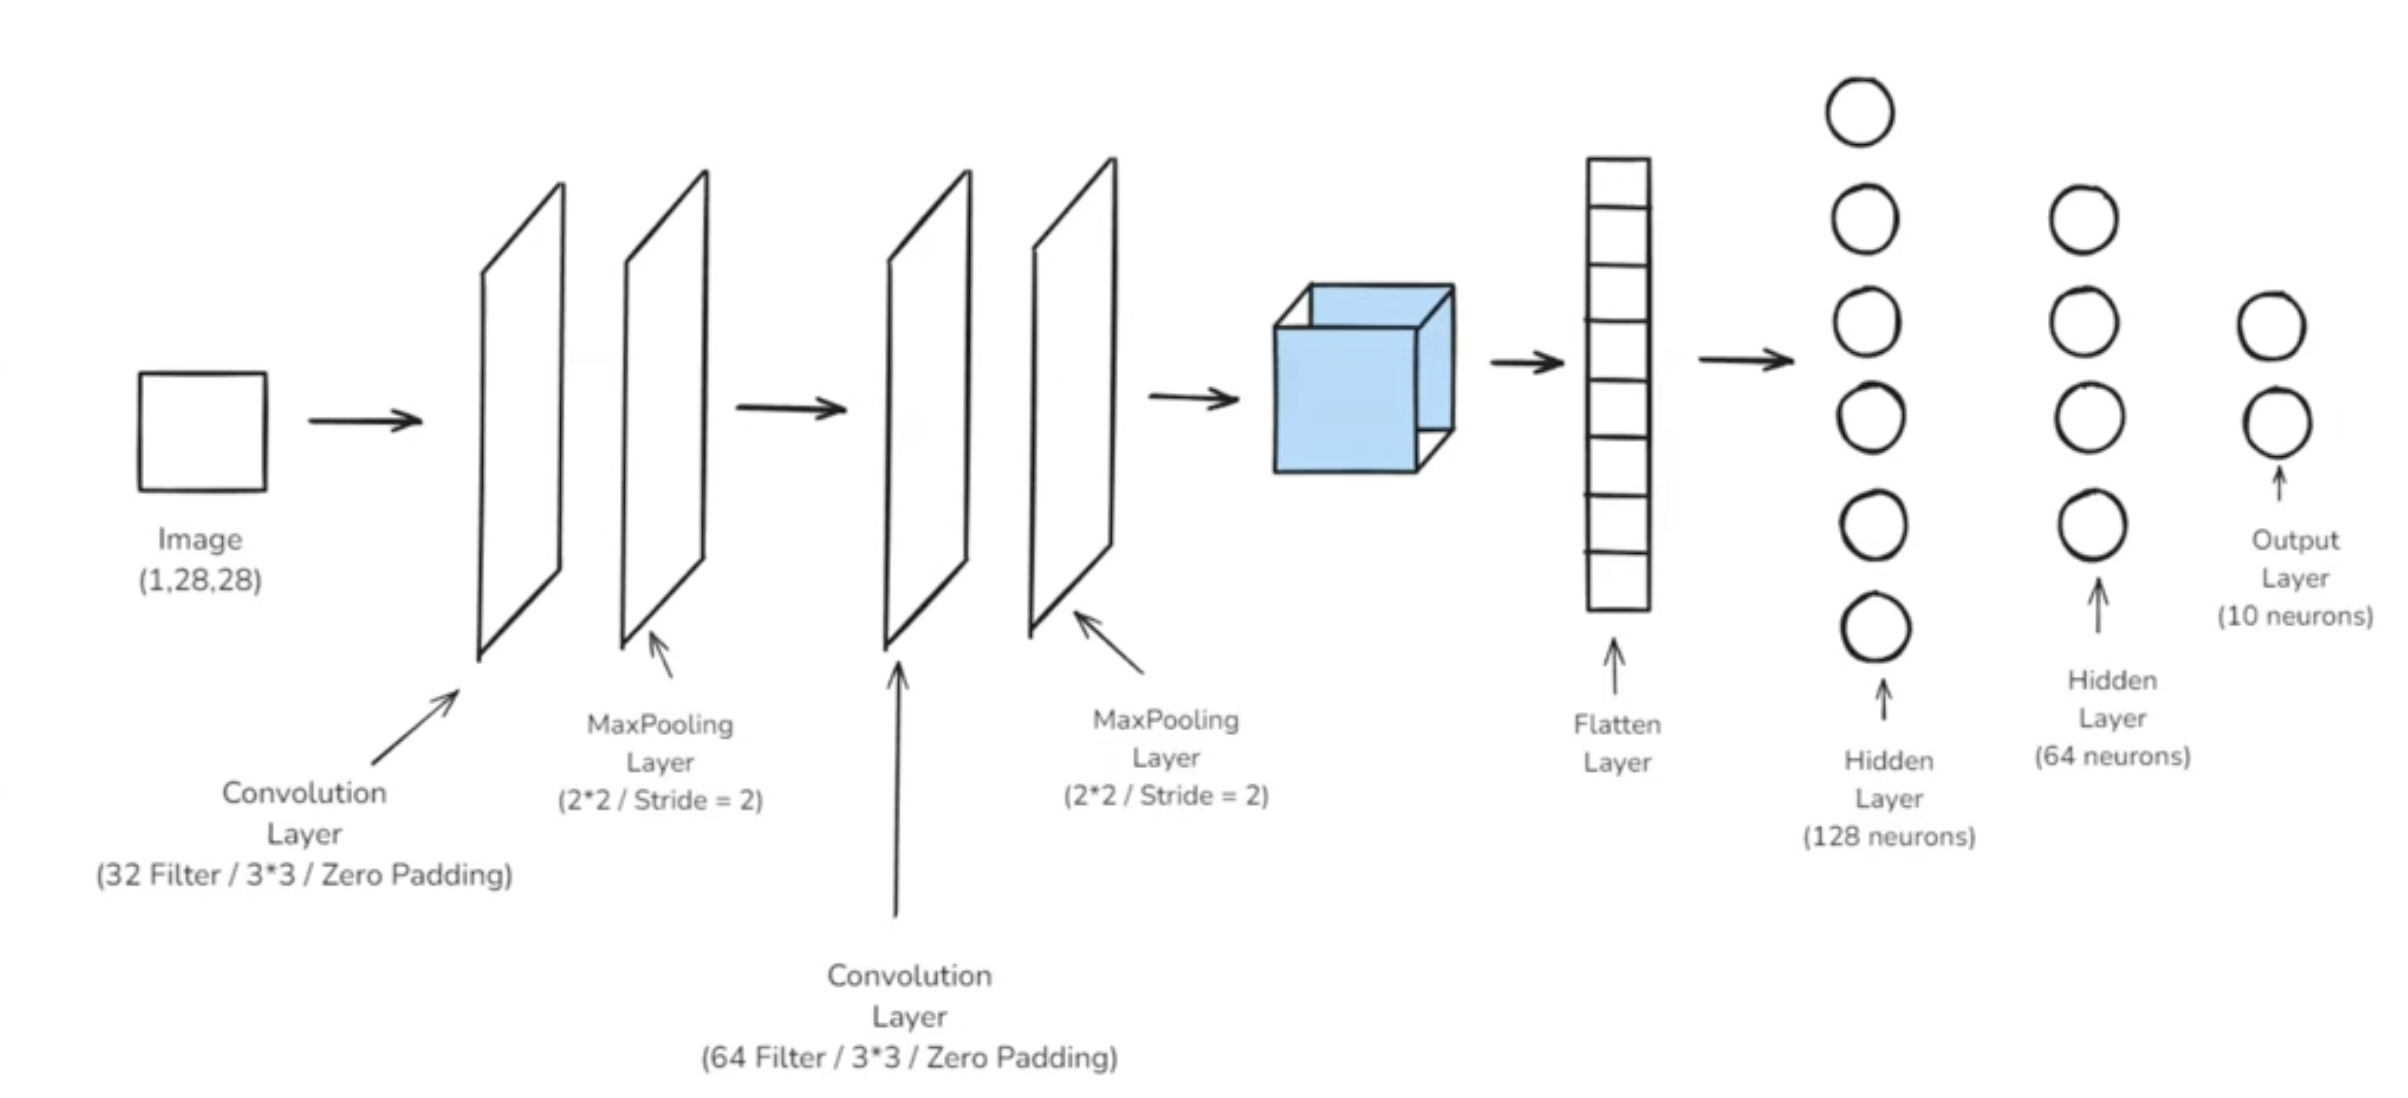

In [ ]:
from IPython.display import Image, display

# Show the architecture diagram (upload the PNG to Colab first)
display(Image(filename='/content/sample_data/Architechture_Diagram.png'))

## Step 0 — Imports & setup

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
# Set random seeds so results are reproducible every run
torch.manual_seed(42)
np.random.seed(42)

**Pick the fastest available hardware.** Training is much faster on a GPU.
- `cuda` → NVIDIA GPU (e.g. Google Colab)
- `mps`  → Apple-Silicon Mac GPU
- `cpu`  → fallback (slower)

In [ ]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

Using device: mps


## Step 1 — Load the dataset

The data is stored as a CSV. Each **row is one image**, stored as flat pixel values.

> Running locally? Keep `fashion-mnist_train.csv` in the same folder as this notebook.
> On Colab, upload the CSV first (the path stays the same).

In [ ]:
import pandas as pd
import torch
from torchvision import datasets

# 1. Load PyTorch dataset
train_data = datasets.FashionMNIST(root="data", train=True, download=True)

# 2. Extract raw image arrays and labels
# train_data.data has shape (60000, 28, 28); we flatten it to (60000, 784)
images_flattened = train_data.data.numpy().reshape(-1, 28 * 28)
labels = train_data.targets.numpy()

# 3. Build the DataFrame matching the CSV structure
df = pd.DataFrame(images_flattened)
df.insert(0, 'label', labels)  # Add label column at index 0

df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### What does the data look like?

Let's check the shape: we expect **60,000 images**, each described by **785 numbers**.

Why 785?  →  **1 label** + **784 pixels**, and `784 = 28 × 28`.
So every row is one 28×28 image *unrolled* into a single line of pixels (values 0–255),
with the first column telling us the correct class.

In [ ]:
df.shape

(60000, 785)

### Give the labels human names

The labels are numbers `0`–`9`, but each number is actually a clothing category.
Let's define the official Fashion-MNIST class names so our plots and predictions are readable.

In [ ]:
class_names = [
    'T-shirt/top',  # 0
    'Trouser',      # 1
    'Pullover',     # 2
    'Dress',        # 3
    'Coat',         # 4
    'Sandal',       # 5
    'Shirt',        # 6
    'Sneaker',      # 7
    'Bag',          # 8
    'Ankle boot'    # 9
]

for i, name in enumerate(class_names):
    print(i, '->', name)

0 -> T-shirt/top
1 -> Trouser
2 -> Pullover
3 -> Dress
4 -> Coat
5 -> Sandal
6 -> Shirt
7 -> Sneaker
8 -> Bag
9 -> Ankle boot


### Peek at 16 sample images

Now we reshape each flat 784-pixel row back into a 28×28 image and display it *with its
real class name*.

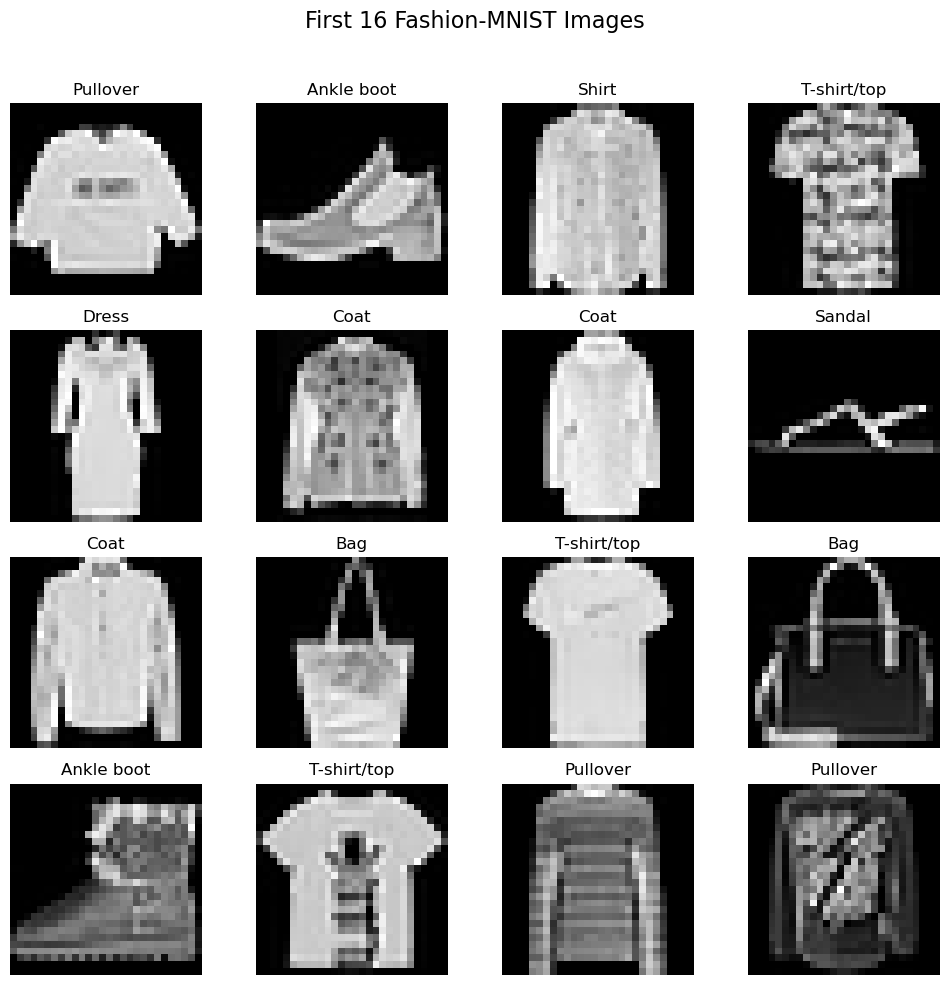

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Fashion-MNIST Images", fontsize=16)

for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)   # 784 pixels -> 28x28
    label = df.iloc[i, 0]
    ax.imshow(img, cmap='gray')                    # grayscale image
    ax.axis('off')
    ax.set_title(f"{class_names[label]}")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Step 2 — Prepare the data for PyTorch

Three things need to happen before we can train:

1. **Split** the pixels (`X`) from the labels (`y`), and hold out 20% as a validation/test set
   so we can measure how well the model does on images it has **never seen**.
2. **Normalise** pixels from `0–255` to `0–1`. Smaller, consistent numbers make training
   faster and more stable.
3. **Wrap** everything in a `Dataset` + `DataLoader` so PyTorch can feed the model data in
   small **batches** (32 images at a time).

In [ ]:
# Separate features (pixels) from the label
X = df.iloc[:, 1:].values   # all pixel columns
y = df.iloc[:, 0].values    # the label column

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train images:", X_train.shape[0], "| Test images:", X_test.shape[0])

Train images: 48000 | Test images: 12000


In [ ]:
# Scale pixel values from 0-255 down to 0-1
X_train = X_train / 255.0
X_test  = X_test / 255.0

**Custom `Dataset`.** PyTorch needs a `Dataset` object that knows how to return one
`(image, label)` pair at a time. The key line is the `.reshape(-1, 1, 28, 28)`:

- `-1` → however many images we have
- `1`  → **1 channel** (grayscale)
- `28, 28` → height and width

This turns each flat 784-vector back into the `(1, 28, 28)` image shape the CNN expects —
exactly the input in our diagram.

In [ ]:
class CustomDataset(Dataset):

    def __init__(self, features, labels):
        # (N, 784) -> (N, 1, 28, 28) so it matches the CNN input shape
        self.features = torch.tensor(features, dtype=torch.float32).reshape(-1, 1, 28, 28)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [ ]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset  = CustomDataset(X_test, y_test)

**`DataLoader`.** Feeds the model **batches** of 32 images.
- `shuffle=True` on training → the model sees data in a different order each epoch (better learning).
- `shuffle=False` on test → order doesn't matter when we're only measuring accuracy.

In [ ]:
pin = (device.type == 'cuda')   # pin_memory only helps on CUDA
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  pin_memory=pin)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, pin_memory=pin)

## Step 3 — Build the CNN

Before writing the code, let's connect each idea from the lecture to what it does **in this
exact network**.

### Convolution

A convolution slides a small **filter** (here a **3×3** grid of learnable weights) across the
image and, at every position, multiplies-and-sums the overlapping pixels to produce **one**
output number. Doing this across the whole image gives a **feature map**.

- **Conv 1** learns **32** different filters → **32** feature maps.
- **Conv 2** learns **64** filters → **64** feature maps.

Early filters tend to detect simple things (edges); later ones combine those into richer
shapes (a collar, a heel).

### Stride & Padding

- **Stride** = how many pixels the filter jumps each step. We use **stride 1**, so the filter
  checks *every* position.
- **Padding** = a border of zeros added around the image. We use `padding='same'` (zero
  padding), which keeps the output the **same** height & width as the input.

Result: with stride 1 + same padding, a `28×28` image stays `28×28` after a conv layer.
We deliberately leave the *shrinking* to the pooling layers.

### Pooling (downsampling)

**MaxPooling 2×2 with stride 2** looks at each little 2×2 window and keeps only the **largest**
value. This:
- **halves** the height and width (`28 → 14`, then `14 → 7`),
- keeps the strongest signals, throws away fine detail,
- makes the network cheaper and a bit robust to small shifts.

Pooling changes only *height & width* — it never changes the number of channels.

### Flatten — where does 3136 come from?

After the two conv + pool blocks our data is a cube of shape `(64, 7, 7)`:
**64 feature maps, each 7×7**.

The Dense (fully-connected) layers can't read a cube — they need a flat list. So we **flatten**:

```
64 × 7 × 7 = 3136
```

That's why the first `Linear` layer has `in_features = 3136`. Getting this number wrong is the
#1 source of CNN bugs — always trace the shapes!

### Three helper layers

- **ReLU** — `max(0, x)`. Adds non-linearity so the network can learn complex patterns.
- **BatchNorm2d** — normalises each channel across the batch. Makes training faster & more stable.
- **Dropout(0.4)** — randomly switches off 40% of neurons *during training only*. Forces the
  network not to over-rely on any one neuron → fights **overfitting**.

### Diagram → code

The `MyNN` class below is split into two parts, matching the diagram:
- **`self.features`** — the convolutional part (Conv → ReLU → BatchNorm → Pool, twice).
- **`self.classifier`** — the fully-connected part (Flatten → 128 → 64 → 10).

Read the layers top-to-bottom and match them against the architecture table above.

In [ ]:
class MyNN(nn.Module):
    def __init__(self, input_features):
        super().__init__()

        # ----- Convolutional feature extractor -----
        self.features = nn.Sequential(
            # Conv Block 1:  (1,28,28) -> (32,28,28) -> pool -> (32,14,14)
            nn.Conv2d(input_features, 32, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Block 2:  (32,14,14) -> (64,14,14) -> pool -> (64,7,7)
            nn.Conv2d(32, 64, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # ----- Fully-connected classifier -----
        self.classifier = nn.Sequential(
            nn.Flatten(),                 # (64,7,7) -> 3136
            nn.Linear(64 * 7 * 7, 128),   # 3136 -> 128
            nn.ReLU(),
            nn.Dropout(p=0.4),

            nn.Linear(128, 64),           # 128 -> 64
            nn.ReLU(),
            nn.Dropout(p=0.4),

            nn.Linear(64, 10)             # 64 -> 10 class scores
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Step 4 — Loss, optimizer & hyperparameters

- **Loss — `CrossEntropyLoss`**: the standard choice for multi-class classification. It expects
  the raw scores (logits) from the last layer and applies softmax internally.
- **Optimizer — `SGD`**: nudges the weights in the direction that reduces the loss.
  - `lr = 0.01` — the step size.
  - `weight_decay = 1e-4` — small L2 penalty that discourages huge weights (regularisation).

> We use **12 epochs** for a quick, interactive demo. Feel free to raise it — accuracy keeps
> improving for a while (at the cost of time).

In [ ]:
learning_rate = 0.01
epochs = 12

In [ ]:
model = MyNN(1)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

model

MyNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

## Step 5 — Train the model

Each **epoch** = one full pass over the training data. For every batch we:
1. **Forward pass** — run images through the model to get predictions.
2. **Compute loss** — how wrong were we?
3. **Backward pass** — `loss.backward()` computes gradients.
4. **Update** — `optimizer.step()` nudges the weights.

We also record **training accuracy** and **test accuracy** every epoch so we can *watch* the
model learn (and later spot overfitting).

In [ ]:
def evaluate(loader):
    """Return accuracy of the model on a given DataLoader."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_features, batch_labels in loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            outputs = model(batch_features)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == batch_labels).sum().item()
            total += batch_labels.size(0)
    return correct / total

In [ ]:
train_losses = []
train_accs = []
test_accs = []

for epoch in range(epochs):

    model.train()
    total_epoch_loss = 0
    correct = 0
    total = 0

    for batch_features, batch_labels in train_loader:

        # move data to the chosen device
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        # forward pass
        outputs = model(batch_features)

        # calculate loss
        loss = criterion(outputs, batch_labels)

        # backward pass + update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # running stats
        total_epoch_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == batch_labels).sum().item()
        total += batch_labels.size(0)

    avg_loss = total_epoch_loss / len(train_loader)
    train_acc = correct / total
    test_acc = evaluate(test_loader)      # accuracy on unseen images

    train_losses.append(avg_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch + 1:2d}/{epochs} | "
          f"Loss: {avg_loss:.4f} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Test Acc: {test_acc:.4f}")

Epoch  1/12 | Loss: 0.6509 | Train Acc: 0.7746 | Test Acc: 0.8748
Epoch  2/12 | Loss: 0.3863 | Train Acc: 0.8675 | Test Acc: 0.8979
Epoch  3/12 | Loss: 0.3246 | Train Acc: 0.8893 | Test Acc: 0.8958
Epoch  4/12 | Loss: 0.2907 | Train Acc: 0.8990 | Test Acc: 0.9075
Epoch  5/12 | Loss: 0.2657 | Train Acc: 0.9100 | Test Acc: 0.9008
Epoch  6/12 | Loss: 0.2464 | Train Acc: 0.9149 | Test Acc: 0.9100
Epoch  7/12 | Loss: 0.2277 | Train Acc: 0.9211 | Test Acc: 0.9055
Epoch  8/12 | Loss: 0.2137 | Train Acc: 0.9259 | Test Acc: 0.9160
Epoch  9/12 | Loss: 0.1956 | Train Acc: 0.9321 | Test Acc: 0.9067
Epoch 10/12 | Loss: 0.1917 | Train Acc: 0.9332 | Test Acc: 0.9143
Epoch 11/12 | Loss: 0.1781 | Train Acc: 0.9376 | Test Acc: 0.9193
Epoch 12/12 | Loss: 0.1669 | Train Acc: 0.9414 | Test Acc: 0.9204


### Visualise training

Two plots tell the whole story:
- **Loss** should steadily go *down*.
- **Accuracy** should go *up*. Watch the gap between the train and test lines.

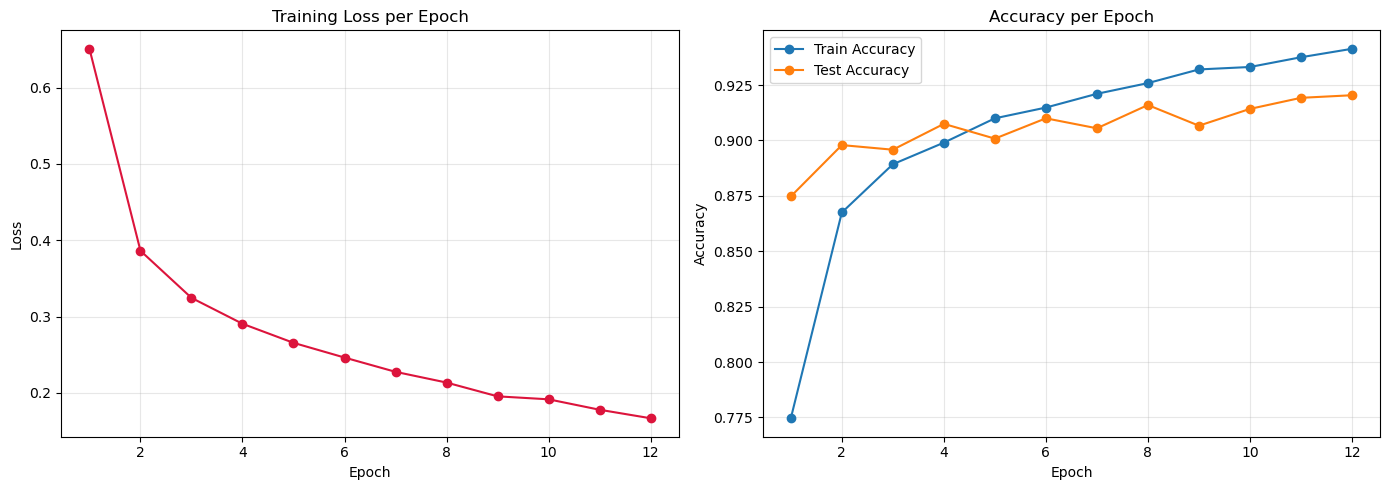

In [ ]:
epochs_range = range(1, epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(epochs_range, train_losses, marker='o', color='crimson')
ax1.set_title("Training Loss per Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(epochs_range, train_accs, marker='o', label='Train Accuracy')
ax2.plot(epochs_range, test_accs,  marker='o', label='Test Accuracy')
ax2.set_title("Accuracy per Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 6 — Final evaluation

Let's measure the final accuracy on both sets (in `eval` mode, so Dropout/BatchNorm behave
correctly).

In [ ]:
final_train_acc = evaluate(train_loader)
final_test_acc  = evaluate(test_loader)

print(f"Final Train Accuracy: {final_train_acc:.4f}")
print(f"Final Test  Accuracy: {final_test_acc:.4f}")
print(f"Gap (Train - Test):   {final_train_acc - final_test_acc:.4f}")

Final Train Accuracy: 0.9625
Final Test  Accuracy: 0.9204
Gap (Train - Test):   0.0421


### A note on overfitting

Notice the **train accuracy is higher than the test accuracy** — often the model reaches
near-perfect scores on training data while test accuracy plateaus around the low-90s%.

That gap is **overfitting**: the model starts *memorising* the training images instead of
learning general patterns. It's completely normal, and it's exactly why we added tools like
**Dropout**, **BatchNorm**, and **weight decay** to keep it in check.

Ways to reduce the gap further: more dropout, data augmentation, early stopping, or a simpler
model. The goal is always **good performance on unseen data**, not a perfect training score.

## Step 7 — Predict a single unseen image

Finally, the fun part. We load one image the model has **never seen** (from the separate
`fashion-mnist_test.csv` file), show it, and let the model guess.

> On Colab, upload `fashion-mnist_test.csv` too. Running locally, keep it in the same folder.

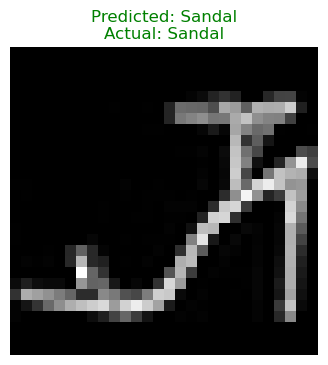

Model predicted : Sandal
Actual label    : Sandal


In [ ]:
# Load the held-out test file
test_df = pd.read_csv('fashion-mnist_test.csv')

# Pick any image (change this index to try different ones!)
index = 15

true_label = test_df.iloc[index, 0]
pixels = test_df.iloc[index, 1:].values.astype('float32')

# Preprocess exactly like training data: scale, reshape, add batch dim
img_tensor = torch.tensor(pixels / 255.0).reshape(1, 1, 28, 28).to(device)

# Predict
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    predicted_label = torch.argmax(output, dim=1).item()

# Show the image with prediction vs truth
plt.figure(figsize=(4, 4))
plt.imshow(pixels.reshape(28, 28), cmap='gray')
plt.axis('off')
plt.title(f"Predicted: {class_names[predicted_label]}\nActual: {class_names[true_label]}",
          color=('green' if predicted_label == true_label else 'red'))
plt.show()

print(f"Model predicted : {class_names[predicted_label]}")
print(f"Actual label    : {class_names[true_label]}")